In [1]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary
from torchvision import datasets, transforms

# CIFAR10 with CNN GAN

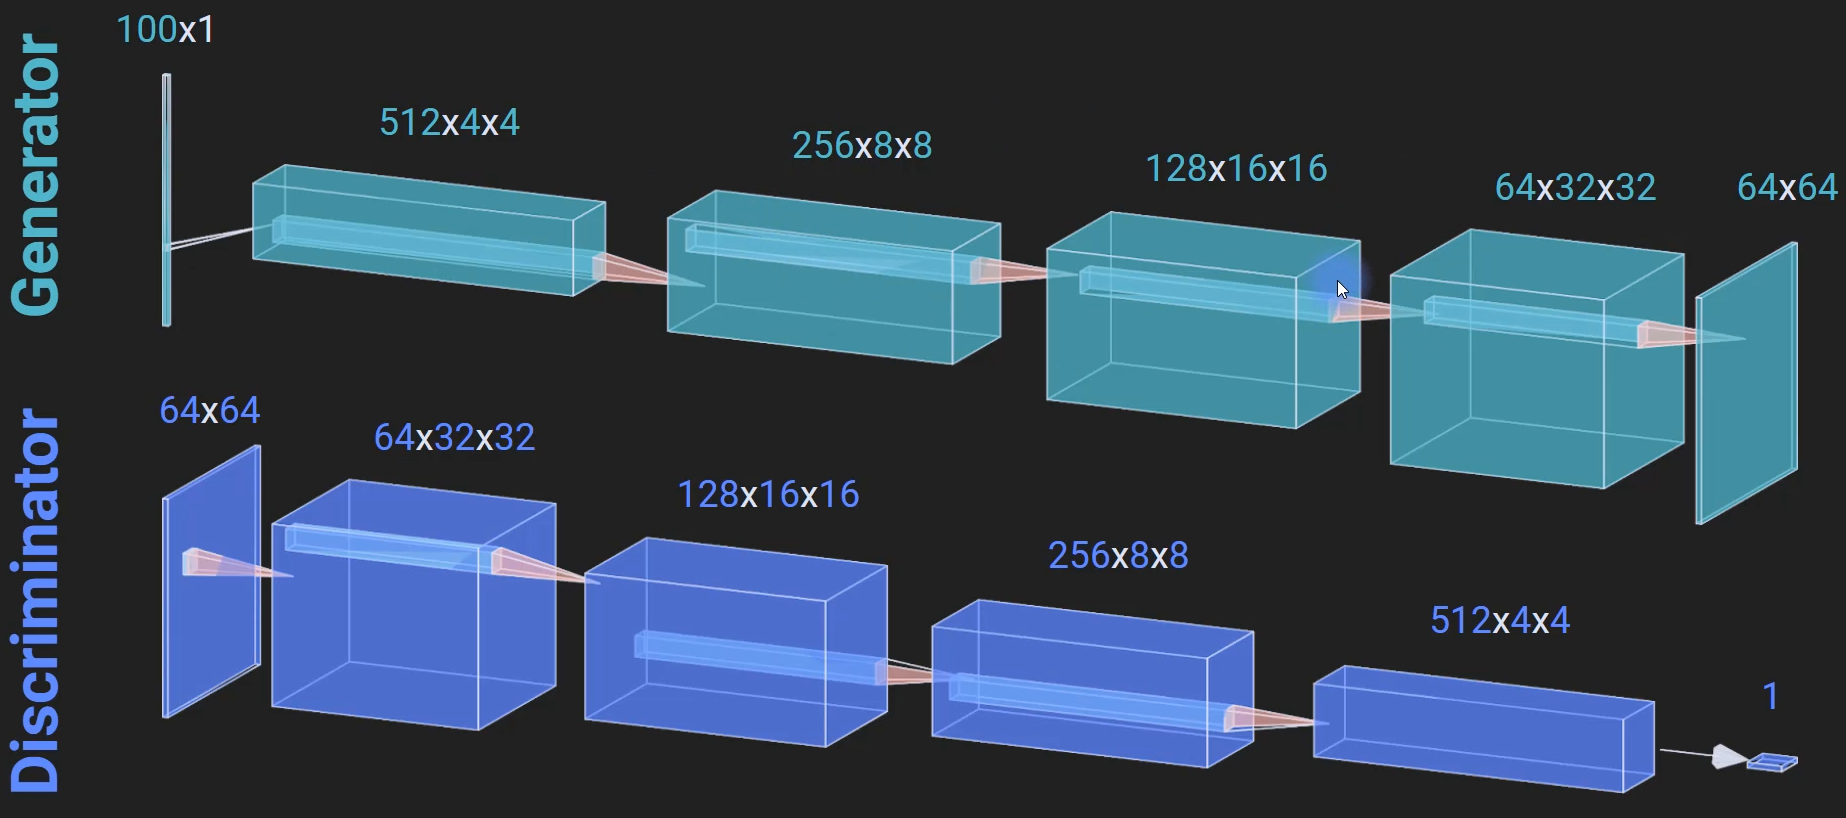

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [3]:
# import mnist dataset

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Resize((64, 64)),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

small_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

data_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)

d:\Pablo_Data\Documentos\VSCode\deep-learning\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [13]:
# create a linear discriminator and generator model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # input size is (3, 64, 64) and output is a single value representing the probability of being real
        # bias=False because we will use batch normalization, which has its own bias term
        self.conv1 = nn.Conv2d( 3,  64, kernel_size=4, stride=2, padding=1, bias=False) # size = (64, 32, 32)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False) # size = (128, 16, 16)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False) # size = (256, 8, 8)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False) # size = (512, 4, 4)
        self.conv5 = nn.Conv2d(512,   1, kernel_size=4, stride=1, padding=0, bias=False) # size = (1, 1, 1)
        
        # Apply batch normalization the the middle layers to stabilize training, but not to the first and last layers since 
        # they are directly connected to the input and output, respectively
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(256)
        self.bn4 = nn.BatchNorm2d(512)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), 0.2) # use leaky relu to avoid dead neurons
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
        x = F.leaky_relu(self.bn4(self.conv4(x)), 0.2)
        x = torch.sigmoid(self.conv5(x)) # output is in range [0, 1] to represent the probability of being real
        return x.view(-1, 1) # flatten the output to a single value per image
    
d_net = Discriminator().to(device)
print(summary(d_net, input_size=(3, 64, 64)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           3,072
            Conv2d-2          [-1, 128, 16, 16]         131,072
       BatchNorm2d-3          [-1, 128, 16, 16]             256
            Conv2d-4            [-1, 256, 8, 8]         524,288
       BatchNorm2d-5            [-1, 256, 8, 8]             512
            Conv2d-6            [-1, 512, 4, 4]       2,097,152
       BatchNorm2d-7            [-1, 512, 4, 4]           1,024
            Conv2d-8              [-1, 1, 1, 1]           8,192
Total params: 2,765,568
Trainable params: 2,765,568
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.05
Forward/backward pass size (MB): 1.38
Params size (MB): 10.55
Estimated Total Size (MB): 11.97
----------------------------------------------------------------
None


In [18]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # input size is a noise vector of size 100 and output is an image of size (1, 64, 64)
        # bias=False because we will use batch normalization, which has its own bias term
        self.conv1 = nn.ConvTranspose2d(100, 512, kernel_size=4, stride=1, padding=0, bias=False) # size = (512, 4, 4)
        self.conv2 = nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False) # size = (256, 8, 8)
        self.conv3 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False) # size = (128, 16, 16)
        self.conv4 = nn.ConvTranspose2d(128,  64, kernel_size=4, stride=2, padding=1, bias=False) # size = (64, 32, 32)
        self.conv5 = nn.ConvTranspose2d( 64,   3, kernel_size=4, stride=2, padding=1, bias=False) # size = (3, 64, 64)

        # here we apply bn to the first layer as well, since it is not directly connected to the input noise vector, but rather to the output of the first convolutional layer
        self.bn1 = nn.BatchNorm2d(512)
        self.bn2 = nn.BatchNorm2d(256)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
        x = F.leaky_relu(self.bn4(self.conv4(x)), 0.2)
        x = torch.tanh(self.conv5(x)) # output is in range [-1, 1] to match the normalized input images
        x = x.view(-1, 3, 64, 64) # reshape the output to image format
        return x
    
g_net = Generator().to(device)
print(summary(g_net, input_size=(100, 1, 1)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
   ConvTranspose2d-1            [-1, 512, 4, 4]         819,200
       BatchNorm2d-2            [-1, 512, 4, 4]           1,024
   ConvTranspose2d-3            [-1, 256, 8, 8]       2,097,152
       BatchNorm2d-4            [-1, 256, 8, 8]             512
   ConvTranspose2d-5          [-1, 128, 16, 16]         524,288
       BatchNorm2d-6          [-1, 128, 16, 16]             256
   ConvTranspose2d-7           [-1, 64, 32, 32]         131,072
       BatchNorm2d-8           [-1, 64, 32, 32]             128
   ConvTranspose2d-9            [-1, 3, 64, 64]           3,072
Total params: 3,576,704
Trainable params: 3,576,704
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 1.97
Params size (MB): 13.64
Estimated Total Size (MB): 15.61
-------------------------------------

In [19]:
# simulate a forward pass through the generator and discriminator to check that the dimensions are correct
noise = torch.randn(1, 100, 1, 1).to(device)
fake_image = g_net(noise)
print(fake_image.shape) # should be (1, 1, 64, 64)
d_out = d_net(fake_image)
print(d_out.shape) # should be (1, 1)

# same for real images
X = next(iter(data_loader))[0].to(device) # get a batch of real images
real_image = X[0].unsqueeze(0) # get a single image and add a batch dimension
print(real_image.shape) # should be (1, 1, 64, 64)
d_out_real = d_net(real_image)
print(d_out_real.shape) # should be (1, 1)

torch.Size([1, 3, 64, 64])
torch.Size([1, 1])
torch.Size([1, 3, 64, 64])
torch.Size([1, 1])


In [20]:
# create a function to train the GAN
def train_gan(d_net, d_optimizer, g_net, g_optimizer, train_loader, loss_fn, num_epochs=10):

    losses = np.zeros((num_epochs, 2)) # to store discriminator and generator losses
    discriminator_outputs = np.zeros((num_epochs, 2)) # to store discriminator outputs for real and fake images

    for epoch in range(num_epochs):
        loss_d_epoch = 0.0
        loss_g_epoch = 0.0
        d_out_real_epoch = 0.0
        d_out_fake_epoch = 0.0
        for real_images, _ in train_loader:
            batch_size = real_images.size(0) # get the actual batch size (last batch might be smaller)
            
            # A) Train Discriminator
            # 0) Create real and fake images and labels
            real_images = real_images.to(device)
            labels_real = torch.ones(batch_size, 1).to(device) # real labels

            noise = torch.randn(batch_size, 100, 1, 1).to(device)
            fake_images = g_net(noise)
            labels_fake = torch.zeros(batch_size, 1).to(device) # fake labels

            # 1) Train on real images
            output_real = d_net(real_images)
            d_loss_real = loss_fn(output_real, labels_real)

            # 2) Train on fake images
            output_fake = d_net(fake_images.detach()) # detach to avoid backprop through generator
            d_loss_fake = loss_fn(output_fake, labels_fake)

            # 3) Combine losses and update discriminator
            d_out_real_epoch += output_real.mean().item() # average output for real images
            d_out_fake_epoch += output_fake.mean().item() # average output for fake images
            loss_d_epoch += d_loss_real.item() + d_loss_fake.item()
            d_loss = d_loss_real + d_loss_fake

            d_optimizer.zero_grad()
            d_loss.backward()
            d_optimizer.step()

            # B) Train Generator
            output_fake_for_g = d_net(fake_images) # don't detach here, we want gradients to flow to generator
            g_loss = loss_fn(output_fake_for_g, labels_real) # want generator to fool discriminator
            loss_g_epoch += g_loss.item()
            g_optimizer.zero_grad()
            g_loss.backward()
            g_optimizer.step()

        discriminator_outputs[epoch, 0] = d_out_real_epoch / len(train_loader) # average discriminator output for real images
        discriminator_outputs[epoch, 1] = d_out_fake_epoch / len(train_loader) # average discriminator output for fake images   
        losses[epoch, 0] = loss_d_epoch / len(train_loader) # average discriminator loss for the epoch
        losses[epoch, 1] = loss_g_epoch / len(train_loader) # average generator loss for the epoch

        print(f"Epoch [{epoch+1}/{num_epochs}] - D Loss: {loss_d_epoch/len(train_loader):.4f}, G Loss: {loss_g_epoch/len(train_loader):.4f}")

    return losses, discriminator_outputs

In [21]:
# define loss function and optimizers for discriminator and generator
loss_fn = nn.BCELoss()

d_net = Discriminator().to(device)
g_net = Generator().to(device)

optimizer_D = torch.optim.Adam(d_net.parameters(), lr=0.0002, betas=(0.5, 0.999)) # GANS are very sensitive to learning rates
optimizer_G = torch.optim.Adam(g_net.parameters(), lr=0.0002, betas=(0.5, 0.999))

num_epochs = 50

losses, discriminator_outputs = train_gan(d_net, optimizer_D, g_net, optimizer_G, data_loader, loss_fn, num_epochs)

KeyboardInterrupt: 

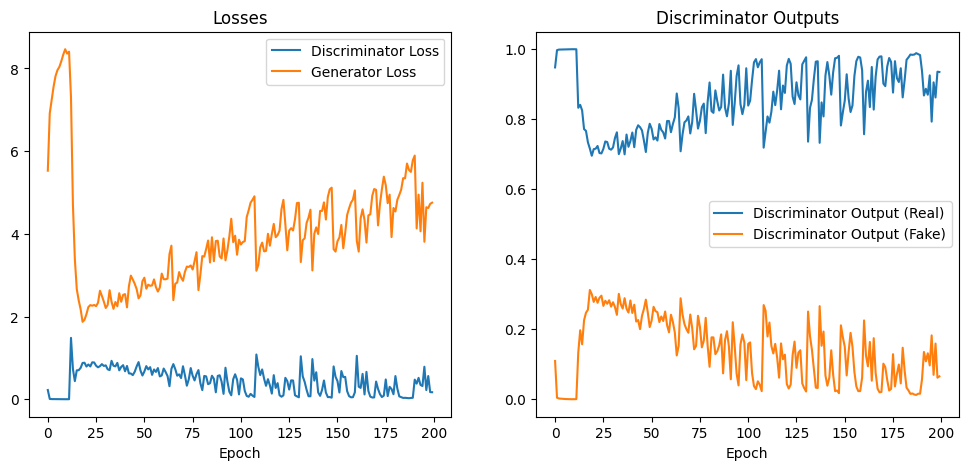

In [9]:
# plot the losses and discriminator outputs
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses[:, 0], label='Discriminator Loss')
plt.plot(losses[:, 1], label='Generator Loss')
plt.title('Losses')
plt.xlabel('Epoch')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(discriminator_outputs[:, 0], label='Discriminator Output (Real)')
plt.plot(discriminator_outputs[:, 1], label='Discriminator Output (Fake)')
plt.title('Discriminator Outputs')
plt.xlabel('Epoch')
plt.legend()
plt.show()
# if observed more in detail, the discriminator and generator loss iterate, this means
# that when the discriminator goes up and it starts to discriminate very well, the generator
# realizes and starts to generate better images, but then the discriminator has more issues to distinguis
# so it is a bucle, where the losses go up and down.

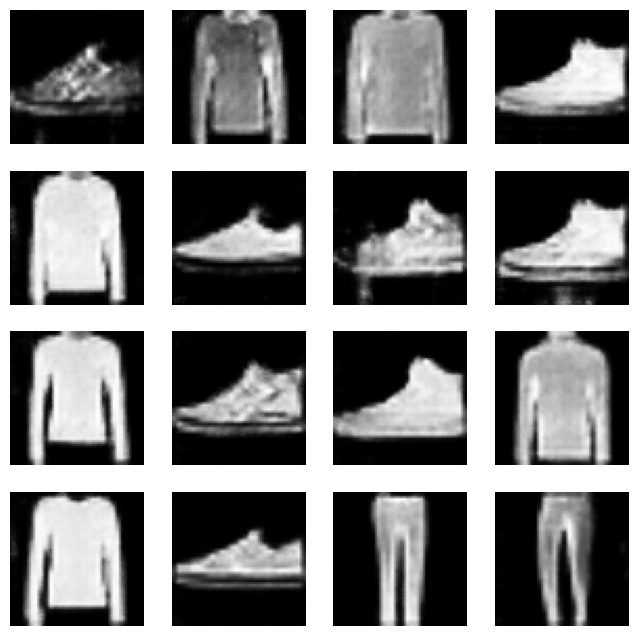

In [ ]:
# visualize some samples
g_net.eval() # set generator to evaluation mode
with torch.no_grad():
    noise = torch.randn(16, 100, 1, 1).to(device) # generate 16 random noise vectors
    fake_images = g_net(noise).cpu() # generate fake images and move to CPU
    fake_images = fake_images.view(-1, 1, 64, 64) # reshape to image format
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(16):
        ax = axes[i//4, i%4]
        ax.imshow(fake_images[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.show()
    
# we obtain better performance than with a linear GAN